# Skip-gram 训练：极大似然估计与梯度下降

基于 14 中的跳元模型，本笔记本实现**极大似然估计（MLE）**下的参数学习，并**逐步可视化**训练过程。

## 1. 数据与符号（与 14 一致）

- 语料、分词、词表 $\mathcal{V}$，$|V|$ 为词表大小。
- $(w_c, w_o)$：中心词与上下文词对。
- 嵌入维度 $d$；$\mathbf{V}_{\mathrm{center}} \in \mathbb{R}^{|V| \times d}$（中心词嵌入），$\mathbf{U}_{\mathrm{outside}} \in \mathbb{R}^{|V| \times d}$（上下文词嵌入）。
- 条件概率（Softmax）：
  $$P(w_o \mid w_c) = \frac{\exp(\mathbf{u}_o^\top \mathbf{v}_c)}{\sum_{i \in \mathcal{V}} \exp(\mathbf{u}_i^\top \mathbf{v}_c)} = \frac{\exp(z_o)}{\sum_{i} \exp(z_i)}, \quad z_i = \mathbf{u}_i^\top \mathbf{v}_c.$$

In [17]:
import numpy as np
from scipy.special import softmax
from itertools import chain
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

# 与 14 相同：语料、分词、词表、中心-上下文对
corpus = [
    "我 喜欢 学习 机器 学习",
    "机器 学习 很 有趣",
    "我 喜欢 编程",
]
window_size = 2

def tokenize(sentences):
    return [s.split() for s in sentences]

def build_vocab(sentences):
    words = sorted(set(chain.from_iterable(sentences)))
    w2i = {w: i for i, w in enumerate(words)}
    i2w = {i: w for w, i in w2i.items()}
    return w2i, i2w, words

def get_center_context_pairs(tokenized, window_size):
    pairs = []
    for sent in tokenized:
        for i, center in enumerate(sent):
            for j in range(max(0, i - window_size), min(len(sent), i + window_size + 1)):
                if i != j:
                    pairs.append((center, sent[j]))
    return pairs

tokenized = tokenize(corpus)
w2i, i2w, vocab = build_vocab(tokenized)
pairs = get_center_context_pairs(tokenized, window_size)
V = len(vocab)
print("词表:", vocab, "|V| =", V)
print("(中心, 上下文) 对数量:", len(pairs))

词表: ['喜欢', '学习', '很', '我', '有趣', '机器', '编程'] |V| = 7
(中心, 上下文) 对数量: 30


In [18]:
embed_dim = 4
np.random.seed(42)

def init_embeddings(V, d):
    V_center = np.random.randn(V, d) * 0.1
    U_outside = np.random.randn(V, d) * 0.1
    return V_center, U_outside

## 一步迭代

## 2. 极大似然估计（MLE）目标与公式

**步骤 1：似然函数**

条件概率之积

给定所有中心-上下文对 $\mathcal{D} = \{(w_c^{(t)}, w_o^{(t)})\}$，似然为各条件概率的乘积：
$$\mathcal{L}(\theta) = \prod_{(w_c, w_o) \in \mathcal{D}} P(w_o \mid w_c).$$

**步骤 2：对数似然（便于求导与数值稳定）**

$$\log \mathcal{L}(\theta) = \sum_{(w_c, w_o) \in \mathcal{D}} \log P(w_o \mid w_c).$$

**步骤 3：负对数似然作为损失（最小化）**

$$J(\theta) = -\log \mathcal{L}(\theta) = -\sum_{(w_c, w_o) \in \mathcal{D}} \log P(w_o \mid w_c).$$

即**交叉熵损失**：对每个样本 $(w_c, w_o)$，损失为 $-\log P(w_o \mid w_c)$；对所有样本求和得到 $J$。

## 3. 单样本损失与 Softmax 梯度

记 $z_i = \mathbf{u}_i^\top \mathbf{v}_c$，$\hat{y}_i = P(\text{词}_i \mid w_c) = \frac{e^{z_i}}{\sum_j e^{z_j}}$，真实上下文词索引为 $o$（one-hot 中为 1 的位置）。

**单样本损失：**
$$J^{(n)} = -\log \hat{y}_o = -\log P(w_o \mid w_c).$$

**对 logits $z_i$ 的梯度（Softmax + 交叉熵的经典结果）：**
$$\frac{\partial J^{(n)}}{\partial z_i} = \hat{y}_i - \mathbb{1}[i = o].$$
即 $\frac{\partial J^{(n)}}{\partial \mathbf{z}} = \hat{\mathbf{y}} - \mathbf{y}_{\text{one-hot}}$。

**对 $\mathbf{v}_c$ 的梯度：** $\mathbf{z} = \mathbf{U}_{\mathrm{outside}} \mathbf{v}_c$，故
$$\frac{\partial J^{(n)}}{\partial \mathbf{v}_c} = \mathbf{U}_{\mathrm{outside}}^\top \frac{\partial J^{(n)}}{\partial \mathbf{z}} = \mathbf{U}_{\mathrm{outside}}^\top (\hat{\mathbf{y}} - \mathbf{y}_{\text{one-hot}}).$$

**对 $\mathbf{U}_{\mathrm{outside}}$（即各 $\mathbf{u}_i$）的梯度：** $\frac{\partial J^{(n)}}{\partial z_i}$ 只通过 $z_i = \mathbf{u}_i^\top \mathbf{v}_c$ 作用到 $\mathbf{u}_i$，故
$$\frac{\partial J^{(n)}}{\partial \mathbf{u}_i} = \frac{\partial J^{(n)}}{\partial z_i} \cdot \mathbf{v}_c.$$
即 $\frac{\partial J^{(n)}}{\partial \mathbf{U}_{\mathrm{outside}}} = (\hat{\mathbf{y}} - \mathbf{y}_{\text{one-hot}}) \otimes \mathbf{v}_c$（外积按行）。

In [19]:
def skipgram_forward(v_c, U_outside):
    """一次 Skip-gram 前向：z = U @ v_c，y_hat = softmax(z) = P(·|w_c)。"""
    z = U_outside @ v_c
    y_hat = softmax(z)
    return y_hat


# 给定 (中心词索引 c, 上下文词索引 o)，计算单样本损失 J^(n) 与梯度
def loss_and_grad(c, o, V_center, U_outside):
    v_c = V_center[c]
    # 前向传播，计算它的条件概率
    y_hat = skipgram_forward(v_c, U_outside)

    # 独热编码：是的。单样本里“真实”上下文只有一个词 w_o，所以目标分布是 one-hot（第 o 维=1）。
    # y_onehot = y_true
    y_true = np.zeros(V)
    y_true[o] = 1.0

    # 单样本损失：J^(n) = -log P(w_o|w_c) = -log y_hat[o]（极大似然对应的交叉熵）
    J = -np.log(y_hat[o] + 1e-10)

    # 反向传播：dz = ∂J/∂z = y_hat - y_onehot；再由 z=U v_c 得 d_v_c = U^T dz，d_U = dz ⊗ v_c（外积）
    dz = y_hat - y_true
    d_v_c = U_outside.T @ dz
    d_U = np.outer(dz, v_c)
    return J, y_hat, d_v_c, d_U

## 4. SGD 更新公式

对参数 $\theta \in \{\mathbf{V}_{\mathrm{center}}, \mathbf{U}_{\mathrm{outside}}\}$，每取一个样本 $(w_c, w_o)$ 做一次更新（SGD）：
$$\theta \leftarrow \theta - \eta \cdot \frac{\partial J^{(n)}}{\partial \theta},$$
其中 $\eta$ 为学习率。

## 5. 训练循环与每步记录

每步（每个样本）做一次 SGD 更新，并记录：当前步损失、梯度范数、以及整表 $P(\cdot\mid w_c)$（用于可视化）。

In [20]:
def train_skipgram_mle(pairs, w2i, V, embed_dim, lr=0.1, max_steps=None, seed=42):
    np.random.seed(seed)
    V_center, U_outside = init_embeddings(V, embed_dim)
    if max_steps is None:
        max_steps = len(pairs) * 20  # 多轮遍历
    indices = [(w2i[w_c], w2i[w_o]) for w_c, w_o in pairs]
    history = []
    step = 0
    while step < max_steps:
        idx = step % len(indices)
        c, o = indices[idx]
        J, y_hat, d_v_c, d_U = loss_and_grad(c, o, V_center, U_outside)
        grad_norm_v = np.linalg.norm(d_v_c)
        grad_norm_u = np.linalg.norm(d_U)
        V_center[c] -= lr * d_v_c
        U_outside -= lr * d_U
        # 记录：步数、损失、梯度范数、当前 P(·|w_c) 分布
        prob_all = softmax(U_outside @ V_center[c])
        history.append({
            'step': step,
            'loss': J,
            'grad_norm_v': grad_norm_v,
            'grad_norm_u': grad_norm_u,
            'center_idx': c,
            'context_idx': o,
            'prob_given_center': prob_all.copy(),
            'V_center': V_center.copy(),
            'U_outside': U_outside.copy(),
        })
        step += 1
    return V_center, U_outside, history

In [21]:
# 运行训练：约 200 步（可调）
V_center, U_outside, history = train_skipgram_mle(
    pairs, w2i, V, embed_dim, lr=0.15, max_steps=200
)
print("训练步数:", len(history))
print("初始损失:", history[0]['loss'])
print("最终损失:", history[-1]['loss'])

训练步数: 200
初始损失: 1.9544642452956327
最终损失: 1.7791823409902858


## 6. 训练过程可视化

以下从 `history` 中抽取并绘制：
1. **损失曲线**：每步的 $J^{(n)}$（单样本负对数似然）
2. **梯度范数**：$\|\partial J/\partial \mathbf{v}_c\|$ 与 $\|\partial J/\partial \mathbf{U}\|$ 随步数变化
3. **当前步概率分布**：选定中心词，展示该步 $P(\cdot \mid w_c)$ 的条形图或热力图（若干步采样）
4. **嵌入演化**：对 $\mathbf{V}_{\mathrm{center}}$ 做 PCA 到 2D，画出若干步的词向量位置变化

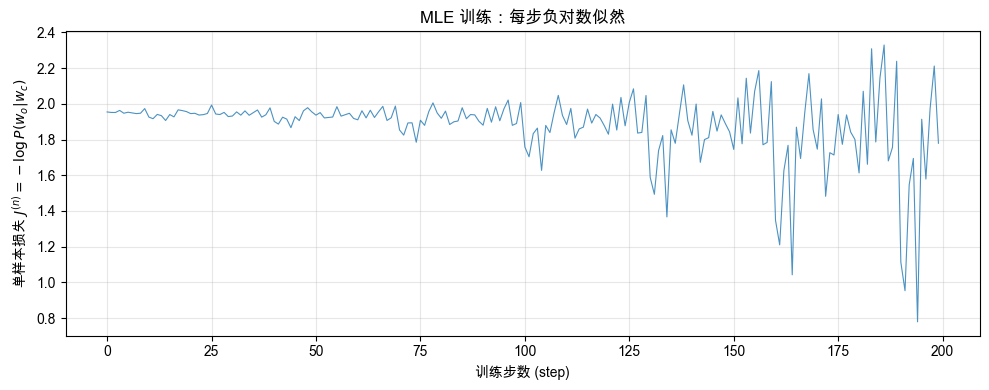

In [22]:
# 1) 损失曲线
steps = [h['step'] for h in history]
losses = [h['loss'] for h in history]
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(steps, losses, alpha=0.8, linewidth=0.8)
ax.set_xlabel('训练步数 (step)')
ax.set_ylabel('单样本损失 $J^{(n)} = -\\log P(w_o|w_c)$')
ax.set_title('MLE 训练：每步负对数似然')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

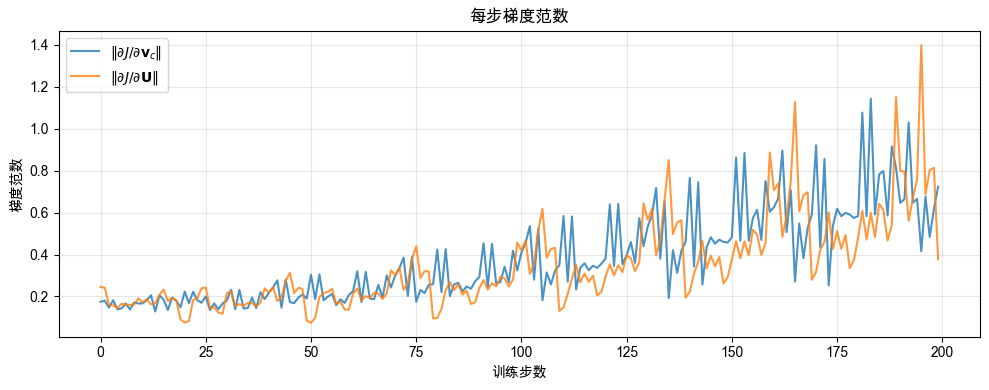

In [23]:
# 2) 梯度范数随步数变化
gv = [h['grad_norm_v'] for h in history]
gu = [h['grad_norm_u'] for h in history]
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(steps, gv, label='$\\|\\partial J/\\partial \\mathbf{v}_c\\|$', alpha=0.8)
ax.plot(steps, gu, label='$\\|\\partial J/\\partial \\mathbf{U}\\|$', alpha=0.8)
ax.set_xlabel('训练步数')
ax.set_ylabel('梯度范数')
ax.set_title('每步梯度范数')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

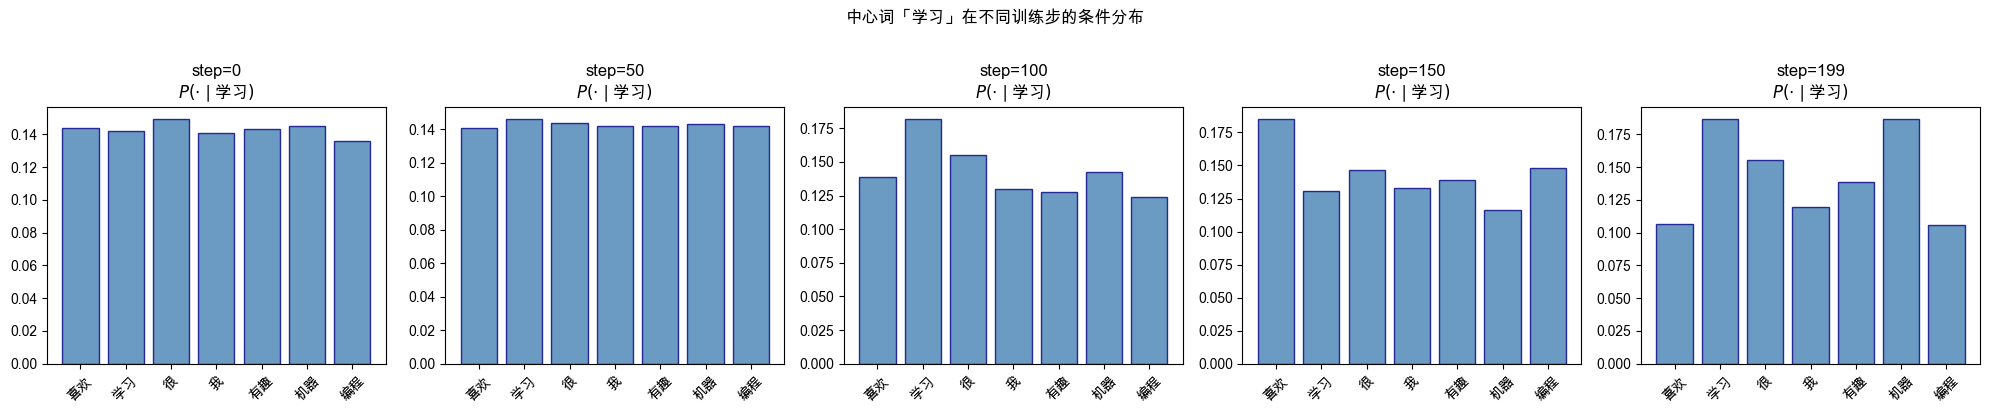

In [24]:
# 3) 选定若干步，展示当前中心词对应的 P(·|w_c) 分布
# 选“学习”作为中心词（索引）
center_word = '学习'
c_idx = w2i[center_word]
# 采样步数：0, 50, 100, 150, 199
sample_steps = [0, 50, 100, 150, min(199, len(history)-1)]
n_plots = len(sample_steps)
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
if n_plots == 1:
    axes = [axes]
for k, st in enumerate(sample_steps):
    h = history[st]
    prob = h['prob_given_center']
    axes[k].bar(vocab, prob, color='steelblue', edgecolor='navy', alpha=0.8)
    axes[k].set_title(f'step={st}\n$P(\\cdot \\mid ${center_word}$)$')
    axes[k].tick_params(axis='x', rotation=45)
plt.suptitle(f'中心词「{center_word}」在不同训练步的条件分布', y=1.02)
plt.tight_layout()
plt.show()

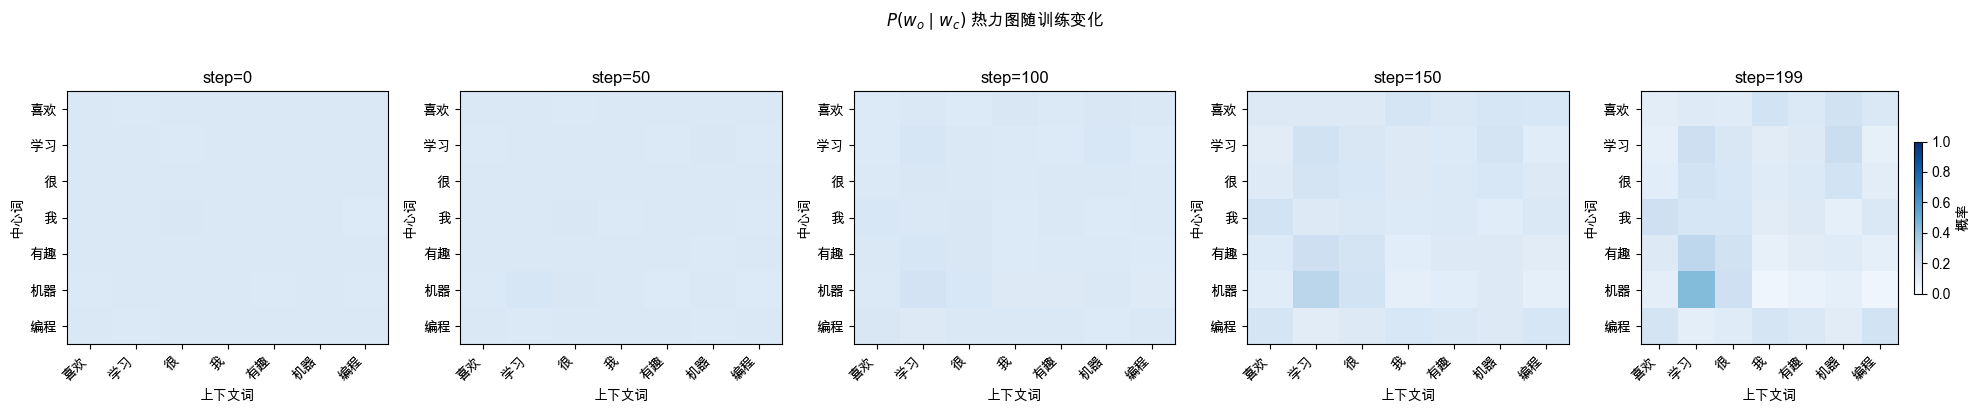

In [25]:
# 4) 概率热力图：行=中心词，列=上下文词，值为 P(上下文|中心)
# 取若干步的 V_center, U_outside 计算整表 P(·|·)
def prob_matrix(V_center, U_outside):
    # P(j|i) = softmax(U @ v_i)[j]
    P = np.zeros((V, V))
    for i in range(V):
        P[i] = softmax(U_outside @ V_center[i])
    return P

sample_steps_heat = [0, 50, 100, 150, min(199, len(history)-1)]
n_heat = len(sample_steps_heat)
fig, axes = plt.subplots(1, n_heat, figsize=(4 * n_heat, 4))
if n_heat == 1:
    axes = [axes]
for k, st in enumerate(sample_steps_heat):
    h = history[st]
    P = prob_matrix(h['V_center'], h['U_outside'])
    im = axes[k].imshow(P, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    axes[k].set_xticks(range(V))
    axes[k].set_yticks(range(V))
    axes[k].set_xticklabels(vocab, rotation=45, ha='right')
    axes[k].set_yticklabels(vocab)
    axes[k].set_xlabel('上下文词')
    axes[k].set_ylabel('中心词')
    axes[k].set_title(f'step={st}')
plt.suptitle('$P(w_o \\mid w_c)$ 热力图随训练变化', y=1.02)
plt.colorbar(im, ax=axes[-1], shrink=0.6, label='概率')
plt.tight_layout()
plt.show()

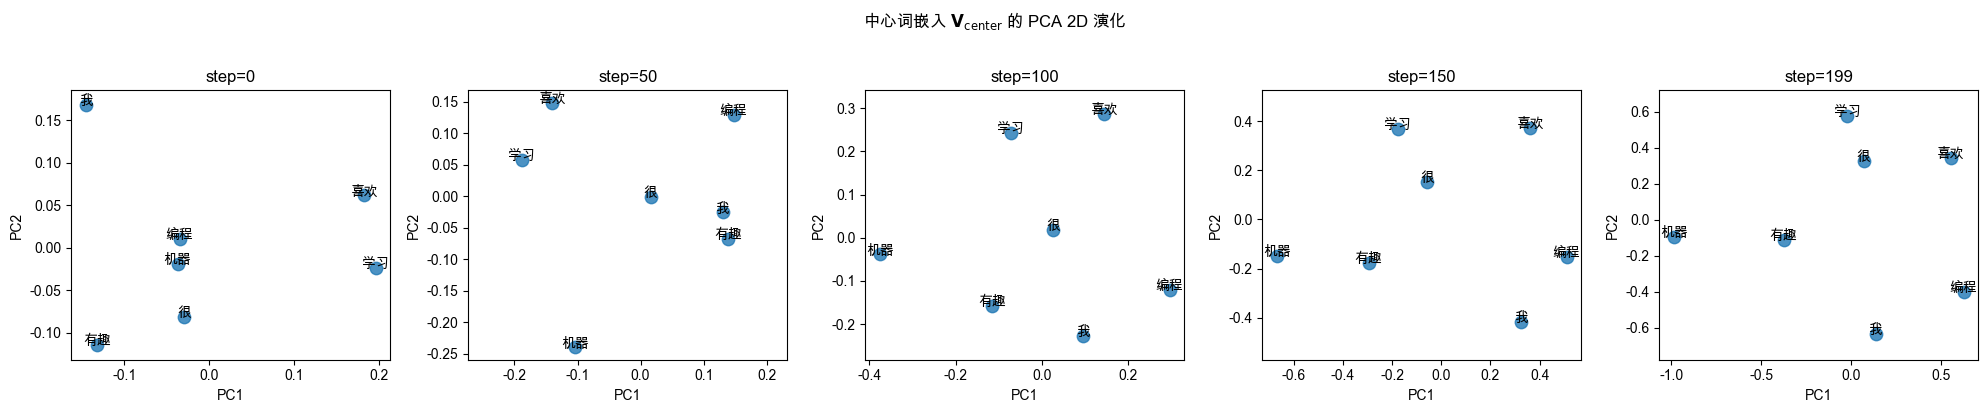

In [26]:
# 5) 嵌入演化：V_center 的 PCA 2D 投影，选若干步画词向量位置
from numpy.linalg import svd

def pca2(X):
    X_centered = X - X.mean(axis=0)
    U, S, Vt = svd(X_centered, full_matrices=False)
    proj = X_centered @ Vt[:2].T
    return proj

sample_steps_embed = [0, 50, 100, 150, min(199, len(history)-1)]
fig, axes = plt.subplots(1, len(sample_steps_embed), figsize=(4 * len(sample_steps_embed), 4))
if len(sample_steps_embed) == 1:
    axes = [axes]
for k, st in enumerate(sample_steps_embed):
    V_c = history[st]['V_center']
    xy = pca2(V_c)
    axes[k].scatter(xy[:, 0], xy[:, 1], s=80, alpha=0.8)
    for i, w in enumerate(vocab):
        axes[k].annotate(w, (xy[i, 0], xy[i, 1]), fontsize=10, ha='center')
    axes[k].set_title(f'step={st}')
    axes[k].set_xlabel('PC1')
    axes[k].set_ylabel('PC2')
    axes[k].axis('equal')
plt.suptitle('中心词嵌入 $\\mathbf{V}_{\\mathrm{center}}$ 的 PCA 2D 演化', y=1.02)
plt.tight_layout()
plt.show()

## 7. 训练后验证：P(上下文|中心) 示例

与 14 中类似，打印若干中心词对应的 $P(w_o \mid w_c)$，检查训练后是否更集中在真实上下文词上。

In [27]:
from collections import defaultdict
grouped = defaultdict(list)
for w_c, w_o in pairs:
    grouped[w_c].append(w_o)
print("训练后 P(上下文词 | 中心词) 示例：\n")
for w_c in sorted(grouped.keys()):
    v_c = V_center[w2i[w_c]]
    probs = softmax(U_outside @ v_c)
    print(f"中心词 「{w_c}」:")
    for w_o in grouped[w_c]:
        p = probs[w2i[w_o]]
        print(f"  P({w_o} | {w_c}) = {p:.6f}")
    print()

训练后 P(上下文词 | 中心词) 示例：

中心词 「喜欢」:
  P(我 | 喜欢) = 0.186062
  P(学习 | 喜欢) = 0.122312
  P(机器 | 喜欢) = 0.189798
  P(我 | 喜欢) = 0.186062
  P(编程 | 喜欢) = 0.141236

中心词 「学习」:
  P(我 | 学习) = 0.110134
  P(喜欢 | 学习) = 0.090852
  P(机器 | 学习) = 0.225938
  P(学习 | 学习) = 0.211065
  P(学习 | 学习) = 0.211065
  P(机器 | 学习) = 0.225938
  P(机器 | 学习) = 0.225938
  P(很 | 学习) = 0.151720
  P(有趣 | 学习) = 0.125641

中心词 「很」:
  P(机器 | 很) = 0.186757
  P(学习 | 很) = 0.186787
  P(有趣 | 很) = 0.138837

中心词 「我」:
  P(喜欢 | 我) = 0.208462
  P(学习 | 我) = 0.158664
  P(喜欢 | 我) = 0.208462
  P(编程 | 我) = 0.144007

中心词 「有趣」:
  P(学习 | 有趣) = 0.274272
  P(很 | 有趣) = 0.194456

中心词 「机器」:
  P(喜欢 | 机器) = 0.100571
  P(学习 | 机器) = 0.440812
  P(学习 | 机器) = 0.440812
  P(学习 | 机器) = 0.440812
  P(很 | 机器) = 0.208013

中心词 「编程」:
  P(我 | 编程) = 0.168265
  P(喜欢 | 编程) = 0.175975

